In [1]:
!pip install requests yfinance tqdm transformers torch -q
print("✅ Done")

✅ Done


(2)IMPORTS

In [2]:
import numpy as np
import pandas as pd
import requests
import yfinance as yf
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings, joblib, json as _json
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from dotenv import load_dotenv
import os

load_dotenv()

API_KEY     = os.getenv("TIINGO_API_KEY")
FINNHUB_KEY = os.getenv("FINNHUB_API_KEY")
GROQ_KEY    = os.getenv("GROQ_API_KEY")

print("✅ Keys loaded")

warnings.filterwarnings("ignore")
print("✅ Imports done | TF:", tf.__version__)

✅ Keys loaded
✅ Imports done | TF: 2.20.0


(3)GPU CHECK

In [3]:
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", len(gpus) if gpus else "None — will use CPU")

GPUs found: None — will use CPU


(4)CONFIGURATION

In [4]:
API_KEY     =  "TIINGO_API_KEY"
STOCKS      = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","AMD","NFLX","INTC"]
START       = "2018-01-01"
END         = "2025-06-03"
WINDOW      = 60
FORECAST    = 7
TRAIN_RATIO = 0.80

FEATURE_COLS = [
    "RETURN_1D","RETURN_5D","MOMENTUM_20","EMA_CROSS",
    "RSI","MACD_HIST_PCT","BB_POS","BB_WIDTH",
    "ATR_PCT","VOL_RATIO","SPY_RETURN","VIX_NORM","DOW"
]
N_FEAT = len(FEATURE_COLS)
print(f"✅ Config | {len(STOCKS)} stocks | {N_FEAT} features | window={WINDOW} | forecast={FORECAST}")

✅ Config | 10 stocks | 13 features | window=60 | forecast=7


(5)DOWNLOAD SPY AND VIX

In [5]:
spy_raw = yf.download("SPY",  start=START, end=END, auto_adjust=True, progress=False).reset_index()
vix_raw = yf.download("^VIX", start=START, end=END, auto_adjust=True, progress=False).reset_index()

for df in [spy_raw, vix_raw]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

spy_raw["Date"] = pd.to_datetime(spy_raw["Date"]).dt.tz_localize(None)
vix_raw["Date"] = pd.to_datetime(vix_raw["Date"]).dt.tz_localize(None)
spy_raw["SPY_RETURN"] = spy_raw["Close"].pct_change()
vix_raw["VIX_NORM"]   = vix_raw["Close"] / 100.0

market = spy_raw[["Date","SPY_RETURN"]].merge(vix_raw[["Date","VIX_NORM"]], on="Date").dropna()
print(f"✅ Market data | rows: {len(market)} | {market['Date'].min().date()} → {market['Date'].max().date()}")

✅ Market data | rows: 1863 | 2018-01-03 → 2025-06-02


In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("TIINGO_API_KEY")

def download_tiingo(ticker):
    url  = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    resp = requests.get(url, params={"startDate":START,"endDate":END,"token":API_KEY})
    data = resp.json()

    # Check for API error
    if isinstance(data, dict):
        print(f"❌ API error for {ticker}: {data}")
        return None

    df = pd.DataFrame(data)
    df["date"]   = pd.to_datetime(df["date"]).dt.tz_localize(None)
    df["Ticker"] = ticker
    return df.sort_values("date").reset_index(drop=True)

# Test key is loaded
print(f"API Key loaded: {'✅' if API_KEY else '❌ KEY IS NONE — check .env file'}")
print(f"Key preview: {API_KEY[:8]}..." if API_KEY else "No key found")

API Key loaded: ❌ KEY IS NONE — check .env file
No key found


In [8]:
import os
print(os.getcwd())

/content


In [9]:
# Run this once to create the .env file directly from the notebook
with open(".env", "w") as f:
    f.write("TIINGO_API_KEY=76e79bea0310025bde0ea382ae51ecb7cc4d561f\n")
    f.write("FINNHUB_API_KEY=your_finnhub_key\n")
    f.write("GROQ_API_KEY=your_groq_key\n")
print("✅ .env created at", os.getcwd())

✅ .env created at /content


In [10]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
API_KEY = os.getenv("TIINGO_API_KEY")
print(f"Key loaded: {'✅' if API_KEY else '❌'}")
print(f"Preview: {API_KEY[:8]}..." if API_KEY else "Still None")

Key loaded: ✅
Preview: 76e79bea...


(6)DOWNLOAD STOCK DATA

In [11]:
def download_tiingo(ticker):
    url  = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
    resp = requests.get(url, params={"startDate":START,"endDate":END,"token":API_KEY})
    df   = pd.DataFrame(resp.json())
    df["date"]   = pd.to_datetime(df["date"]).dt.tz_localize(None)
    df["Ticker"] = ticker
    return df.sort_values("date").reset_index(drop=True)

raw_frames = []
for ticker in tqdm(STOCKS, desc="Downloading"):
    raw_frames.append(download_tiingo(ticker))

raw_df = pd.concat(raw_frames, ignore_index=True)
print(f"✅ Stock data | rows: {len(raw_df)} | stocks: {raw_df['Ticker'].nunique()}")

Downloading: 100%|██████████| 10/10 [00:06<00:00,  1.56it/s]

✅ Stock data | rows: 18650 | stocks: 10


(7)MERGE MARKET DATA

In [12]:
raw_df["date"] = pd.to_datetime(raw_df["date"]).dt.tz_localize(None)
raw_df = raw_df.merge(market, left_on="date", right_on="Date", how="left")
print(f"✅ Merged | missing SPY: {raw_df['SPY_RETURN'].isna().mean()*100:.1f}%")

✅ Merged | missing SPY: 0.1%


(8)FEATURE ENGINEERING

In [13]:
def engineer_features(df):
    df = df.copy().sort_values("date").reset_index(drop=True)
    c, v = df["adjClose"], df["adjVolume"]

    df["RETURN_1D"]   = c.pct_change(1)
    df["RETURN_5D"]   = c.pct_change(5)
    df["MOMENTUM_20"] = (c - c.shift(20)) / c.shift(20)

    ema10 = c.ewm(span=10, adjust=False).mean()
    ema30 = c.ewm(span=30, adjust=False).mean()
    df["EMA_CROSS"] = (ema10 - ema30) / c

    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df["RSI"] = 100 - (100 / (1 + gain / loss))

    macd   = c.ewm(span=12).mean() - c.ewm(span=26).mean()
    signal = macd.ewm(span=9).mean()
    df["MACD_HIST_PCT"] = (macd - signal) / c

    sma20, std20 = c.rolling(20).mean(), c.rolling(20).std()
    bb_up = sma20 + 2*std20
    bb_lo = sma20 - 2*std20
    df["BB_POS"]   = (c - bb_lo) / (bb_up - bb_lo + 1e-9)
    df["BB_WIDTH"] = (bb_up - bb_lo) / c

    hl = df["adjHigh"] - df["adjLow"]
    hc = (df["adjHigh"] - c.shift()).abs()
    lc = (df["adjLow"]  - c.shift()).abs()
    df["ATR_PCT"] = pd.concat([hl,hc,lc], axis=1).max(axis=1).rolling(14).mean() / c

    df["VOL_RATIO"] = v / (v.rolling(20).mean() + 1e-9)
    df["DOW"]       = df["date"].dt.dayofweek / 4.0

    df["SPY_RETURN"] = df["SPY_RETURN"].ffill()
    df["VIX_NORM"]   = df["VIX_NORM"].ffill()
    return df

print("✅ Feature function defined")

✅ Feature function defined


(9)APPLY FEATURES



In [14]:
feat_df = raw_df.groupby("Ticker", group_keys=False).apply(engineer_features)

# Drop rows where any feature is NaN (Stock_ID no longer needed)
cols_to_check = [c for c in FEATURE_COLS if c in feat_df.columns]
feat_df = feat_df.dropna(subset=cols_to_check).reset_index(drop=True)

print(f"✅ Features done | total rows: {len(feat_df)}")
feat_df[["date","Ticker"] + FEATURE_COLS].tail(3)

✅ Features done | total rows: 18450


,date,Ticker,RETURN_1D,RETURN_5D,MOMENTUM_20,EMA_CROSS,RSI,MACD_HIST_PCT,BB_POS,BB_WIDTH,ATR_PCT,VOL_RATIO,SPY_RETURN,VIX_NORM,DOW
18447,2025-05-30,TSLA,-0.033396,0.015893,0.235063,0.080279,68.338152,0.001871,0.668771,0.349362,0.044848,1.177930,-0.001118,0.1857,1.00
18448,2025-06-02,TSLA,-0.010881,0.009872,0.193169,0.075204,60.563135,-0.001840,0.619559,0.338870,0.043412,0.793392,0.005633,0.1836,0.00
18449,2025-06-03,TSLA,0.004611,-0.051310,0.228395,0.069980,55.051506,-0.004294,0.614210,0.311897,0.041536,0.960308,0.005633,0.1836,0.25


(10)TRAIN ONE MODEL PER STOCK

In [15]:
def build_regressor():
    m = Sequential([
        GRU(128, return_sequences=True, input_shape=(WINDOW, N_FEAT)),
        Dropout(0.20),
        GRU(64),
        Dropout(0.15),
        Dense(32, activation="relu"),
        Dense(FORECAST, activation="linear")
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return m

def build_classifier():
    m = Sequential([
        GRU(128, return_sequences=True, input_shape=(WINDOW, N_FEAT)),
        Dropout(0.20),
        GRU(64),
        Dropout(0.15),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")    # outputs P(UP) for Day 1
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
    return m

stock_regressors  = {}
stock_classifiers = {}
stock_scalers     = {}
stock_Xte         = {}
stock_yte_pct     = {}
stock_yte_dir     = {}
stock_tdf         = {}
stock_tgt_mean    = {}
stock_tgt_std     = {}

for ticker in STOCKS:
    print(f"\n{'─'*45}  {ticker}")

    tdf = feat_df[feat_df["Ticker"]==ticker].sort_values("date").reset_index(drop=True)
    c   = tdf["adjClose"].values

    # Targets: % returns (for regressor)
    tgts_pct = np.array(
        [(c[t+1:t+1+FORECAST] - c[t]) / c[t] * 100 for t in range(len(c)-FORECAST)],
        dtype=np.float32
    )
    # Direction target: 1=UP, 0=DOWN for Day 1 (for classifier)
    tgts_dir = (tgts_pct[:, 0] > 0).astype(np.float32)

    tdf = tdf.iloc[:len(tgts_pct)].reset_index(drop=True)
    split = int(len(tdf) * TRAIN_RATIO)

    # Standardize regression targets
    tgt_mean = tgts_pct[:split].mean(axis=0)
    tgt_std  = tgts_pct[:split].std(axis=0) + 1e-8
    tgts_z   = (tgts_pct - tgt_mean) / tgt_std

    stock_tgt_mean[ticker] = tgt_mean
    stock_tgt_std[ticker]  = tgt_std

    # Scale features
    sc = MinMaxScaler()
    sc.fit(tdf.iloc[:split][FEATURE_COLS])
    fs = sc.transform(tdf[FEATURE_COLS].values)

    # Build sequences
    X, y_z, y_dir = [], [], []
    for i in range(len(tgts_z) - WINDOW):
        X.append(fs[i:i+WINDOW])
        y_z.append(tgts_z[i+WINDOW])
        y_dir.append(tgts_dir[i+WINDOW])
    X     = np.array(X,     dtype=np.float32)
    y_z   = np.array(y_z,   dtype=np.float32)
    y_dir = np.array(y_dir, dtype=np.float32)

    split_seq = int(len(X) * TRAIN_RATIO)
    Xtr, Xte  = X[:split_seq],   X[split_seq:]
    ytr_z,yte_z     = y_z[:split_seq],   y_z[split_seq:]
    ytr_dir,yte_dir = y_dir[:split_seq], y_dir[split_seq:]

    cb = [EarlyStopping(monitor="val_loss", patience=12,
                        restore_best_weights=True, verbose=0),
          ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=6, min_lr=1e-6, verbose=0)]

    # Train regressor
    reg = build_regressor()
    reg.fit(Xtr, ytr_z, validation_data=(Xte, yte_z),
            epochs=80, batch_size=32, callbacks=cb, verbose=0)

    # Train classifier
    clf = build_classifier()
    clf.fit(Xtr, ytr_dir, validation_data=(Xte, yte_dir),
            epochs=80, batch_size=32, callbacks=cb, verbose=0)

    # Evaluate
    preds_z   = reg.predict(Xte, verbose=0)
    preds_pct = preds_z * tgt_std + tgt_mean
    probs     = clf.predict(Xte, verbose=0).flatten()   # P(UP)
    yte_pct   = yte_z * tgt_std + tgt_mean

    dacc = np.mean((probs>0.5) == (yte_dir>0.5)) * 100
    prob_std = probs.std()
    print(f"  Dir Acc: {dacc:.1f}%  |  Prob std: {prob_std:.3f}  |  Mean P(UP): {probs.mean():.3f}")

    stock_regressors[ticker]  = reg
    stock_classifiers[ticker] = clf
    stock_scalers[ticker]     = sc
    stock_Xte[ticker]         = Xte
    stock_yte_pct[ticker]     = yte_pct
    stock_yte_dir[ticker]     = yte_dir
    stock_tdf[ticker]         = tdf

print("\n✅ All 10 stocks — regressor + classifier trained")


─────────────────────────────────────────────  AAPL
  Dir Acc: 53.4%  |  Prob std: 0.010  |  Mean P(UP): 0.522

─────────────────────────────────────────────  MSFT
  Dir Acc: 53.7%  |  Prob std: 0.008  |  Mean P(UP): 0.541

─────────────────────────────────────────────  GOOGL
  Dir Acc: 56.2%  |  Prob std: 0.015  |  Mean P(UP): 0.558

─────────────────────────────────────────────  AMZN
  Dir Acc: 53.1%  |  Prob std: 0.005  |  Mean P(UP): 0.497

─────────────────────────────────────────────  META
  Dir Acc: 53.9%  |  Prob std: 0.009  |  Mean P(UP): 0.524

─────────────────────────────────────────────  NVDA
  Dir Acc: 54.8%  |  Prob std: 0.005  |  Mean P(UP): 0.547

─────────────────────────────────────────────  TSLA
  Dir Acc: 54.8%  |  Prob std: 0.021  |  Mean P(UP): 0.495

─────────────────────────────────────────────  AMD
  Dir Acc: 52.0%  |  Prob std: 0.006  |  Mean P(UP): 0.492

─────────────────────────────────────────────  NFLX
  Dir Acc: 46.1%  |  Prob std: 0.003  |  Mean P(UP)

(11)EVALUATE ALL STOCKS

In [17]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 75)
print("  EVALUATION METRICS — ALL 10 STOCKS")
print("=" * 75)

all_results = {}

for ticker in STOCKS:
    Xte      = stock_Xte[ticker]
    yte_pct  = stock_yte_pct[ticker]
    yte_dir  = stock_yte_dir[ticker]
    tdf      = stock_tdf[ticker]
    reg      = stock_regressors[ticker]
    clf      = stock_classifiers[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]

    # Regressor predictions → back to %
    preds_z   = reg.predict(Xte, verbose=0)
    preds_pct = preds_z * tgt_std + tgt_mean

    # Classifier predictions → P(UP)
    probs = clf.predict(Xte, verbose=0).flatten()

    # Reconstruct prices
    split      = int(len(tdf) * TRAIN_RATIO)
    prices_arr = tdf["adjClose"].values[split + WINDOW : split + WINDOW + len(yte_pct)]
    n          = min(len(prices_arr), len(yte_pct))
    prices_arr = prices_arr[:n]
    pp         = preds_pct[:n]
    yp         = yte_pct[:n]

    actual_prices = prices_arr * (1 + yp[:,0]/100)
    pred_prices   = prices_arr * (1 + pp[:,0]/100)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
    mae  = mean_absolute_error(actual_prices, pred_prices)
    mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100
    r2   = r2_score(actual_prices, pred_prices)

    # Directional accuracy per day (from regressor)
    dir_per_day = [np.mean((pp[:,d]>0)==(yp[:,d]>0))*100 for d in range(FORECAST)]

    # Classification metrics (from classifier)
    pred_dir = (probs > 0.5).astype(int)
    true_dir = yte_dir[:len(probs)].astype(int)
    dacc     = np.mean(pred_dir == true_dir) * 100

    tp = np.sum((pred_dir==1) & (true_dir==1))
    tn = np.sum((pred_dir==0) & (true_dir==0))
    fp = np.sum((pred_dir==1) & (true_dir==0))
    fn = np.sum((pred_dir==0) & (true_dir==1))
    precision = tp / (tp + fp + 1e-9) * 100
    recall    = tp / (tp + fn + 1e-9) * 100
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    all_results[ticker] = {
        "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2,
        "DirAcc": dacc, "DirPerDay": dir_per_day,
        "Precision": precision, "Recall": recall, "F1": f1
    }

# ── Summary Table ──
print(f"\n  {'Ticker':<6}  {'RMSE':>7}  {'MAE':>7}  {'MAPE':>7}  {'R²':>6}  {'DirAcc':>8}  {'F1':>6}")
print("  " + "─"*62)
for ticker in STOCKS:
    r = all_results[ticker]
    flag = "✅" if r["DirAcc"]>53 else ("⚠️" if r["DirAcc"]>50 else "❌")
    print(f"  {ticker:<6}  ${r['RMSE']:>6.2f}  ${r['MAE']:>6.2f}  {r['MAPE']:>6.2f}%  "
          f"{r['R2']:>6.3f}  {r['DirAcc']:>7.1f}%  {r['F1']:>5.1f}%  {flag}")

# ── Dir Acc Per Day ──
print(f"\n{'─'*75}")
print("  DIRECTIONAL ACCURACY PER FORECAST DAY (from regressor)")
print(f"{'─'*75}")
print(f"  {'Ticker':<6}" + "".join([f"  Day{d+1}" for d in range(FORECAST)]))
print("  " + "─"*60)
for ticker in STOCKS:
    row = f"  {ticker:<6}"
    for acc in all_results[ticker]["DirPerDay"]:
        row += f"  {acc:>4.1f}%"
    print(row)

# ── Precision / Recall / F1 ──
print(f"\n{'─'*75}")
print("  CLASSIFICATION METRICS — CLASSIFIER MODEL")
print(f"{'─'*75}")
print(f"  {'Ticker':<6}  {'Precision':>10}  {'Recall':>8}  {'F1 Score':>10}")
print("  " + "─"*42)
for ticker in STOCKS:
    r = all_results[ticker]
    print(f"  {ticker:<6}  {r['Precision']:>9.1f}%  {r['Recall']:>7.1f}%  {r['F1']:>9.1f}%")

  EVALUATION METRICS — ALL 10 STOCKS

  Ticker     RMSE      MAE     MAPE      R²    DirAcc      F1
  ──────────────────────────────────────────────────────────────
  AAPL    $  3.24  $  2.32    1.10%   0.982     53.4%   69.0%  ✅
  MSFT    $  5.43  $  3.99    0.97%   0.935     53.7%   69.8%  ✅
  GOOGL   $  3.08  $  2.19    1.30%   0.958     56.2%   71.9%  ✅
  AMZN    $  3.46  $  2.59    1.32%   0.967     53.1%   42.6%  ✅
  META    $ 12.27  $  8.25    1.48%   0.967     53.9%   70.1%  ✅
  NVDA    $  4.11  $  3.05    2.57%   0.951     54.8%   70.8%  ✅
  TSLA    $ 12.01  $  7.89    2.91%   0.979     54.8%   51.7%  ✅
  AMD     $  4.39  $  3.15    2.21%   0.977     52.0%   19.0%  ⚠️
  NFLX    $  1.67  $  1.11    1.36%   0.990     46.1%    0.0%  ❌
  INTC    $  0.87  $  0.58    2.33%   0.984     53.7%    4.6%  ✅

───────────────────────────────────────────────────────────────────────────
  DIRECTIONAL ACCURACY PER FORECAST DAY (from regressor)
──────────────────────────────────────────────────

(12)PLOT ACTUAL V/S PREDICTED

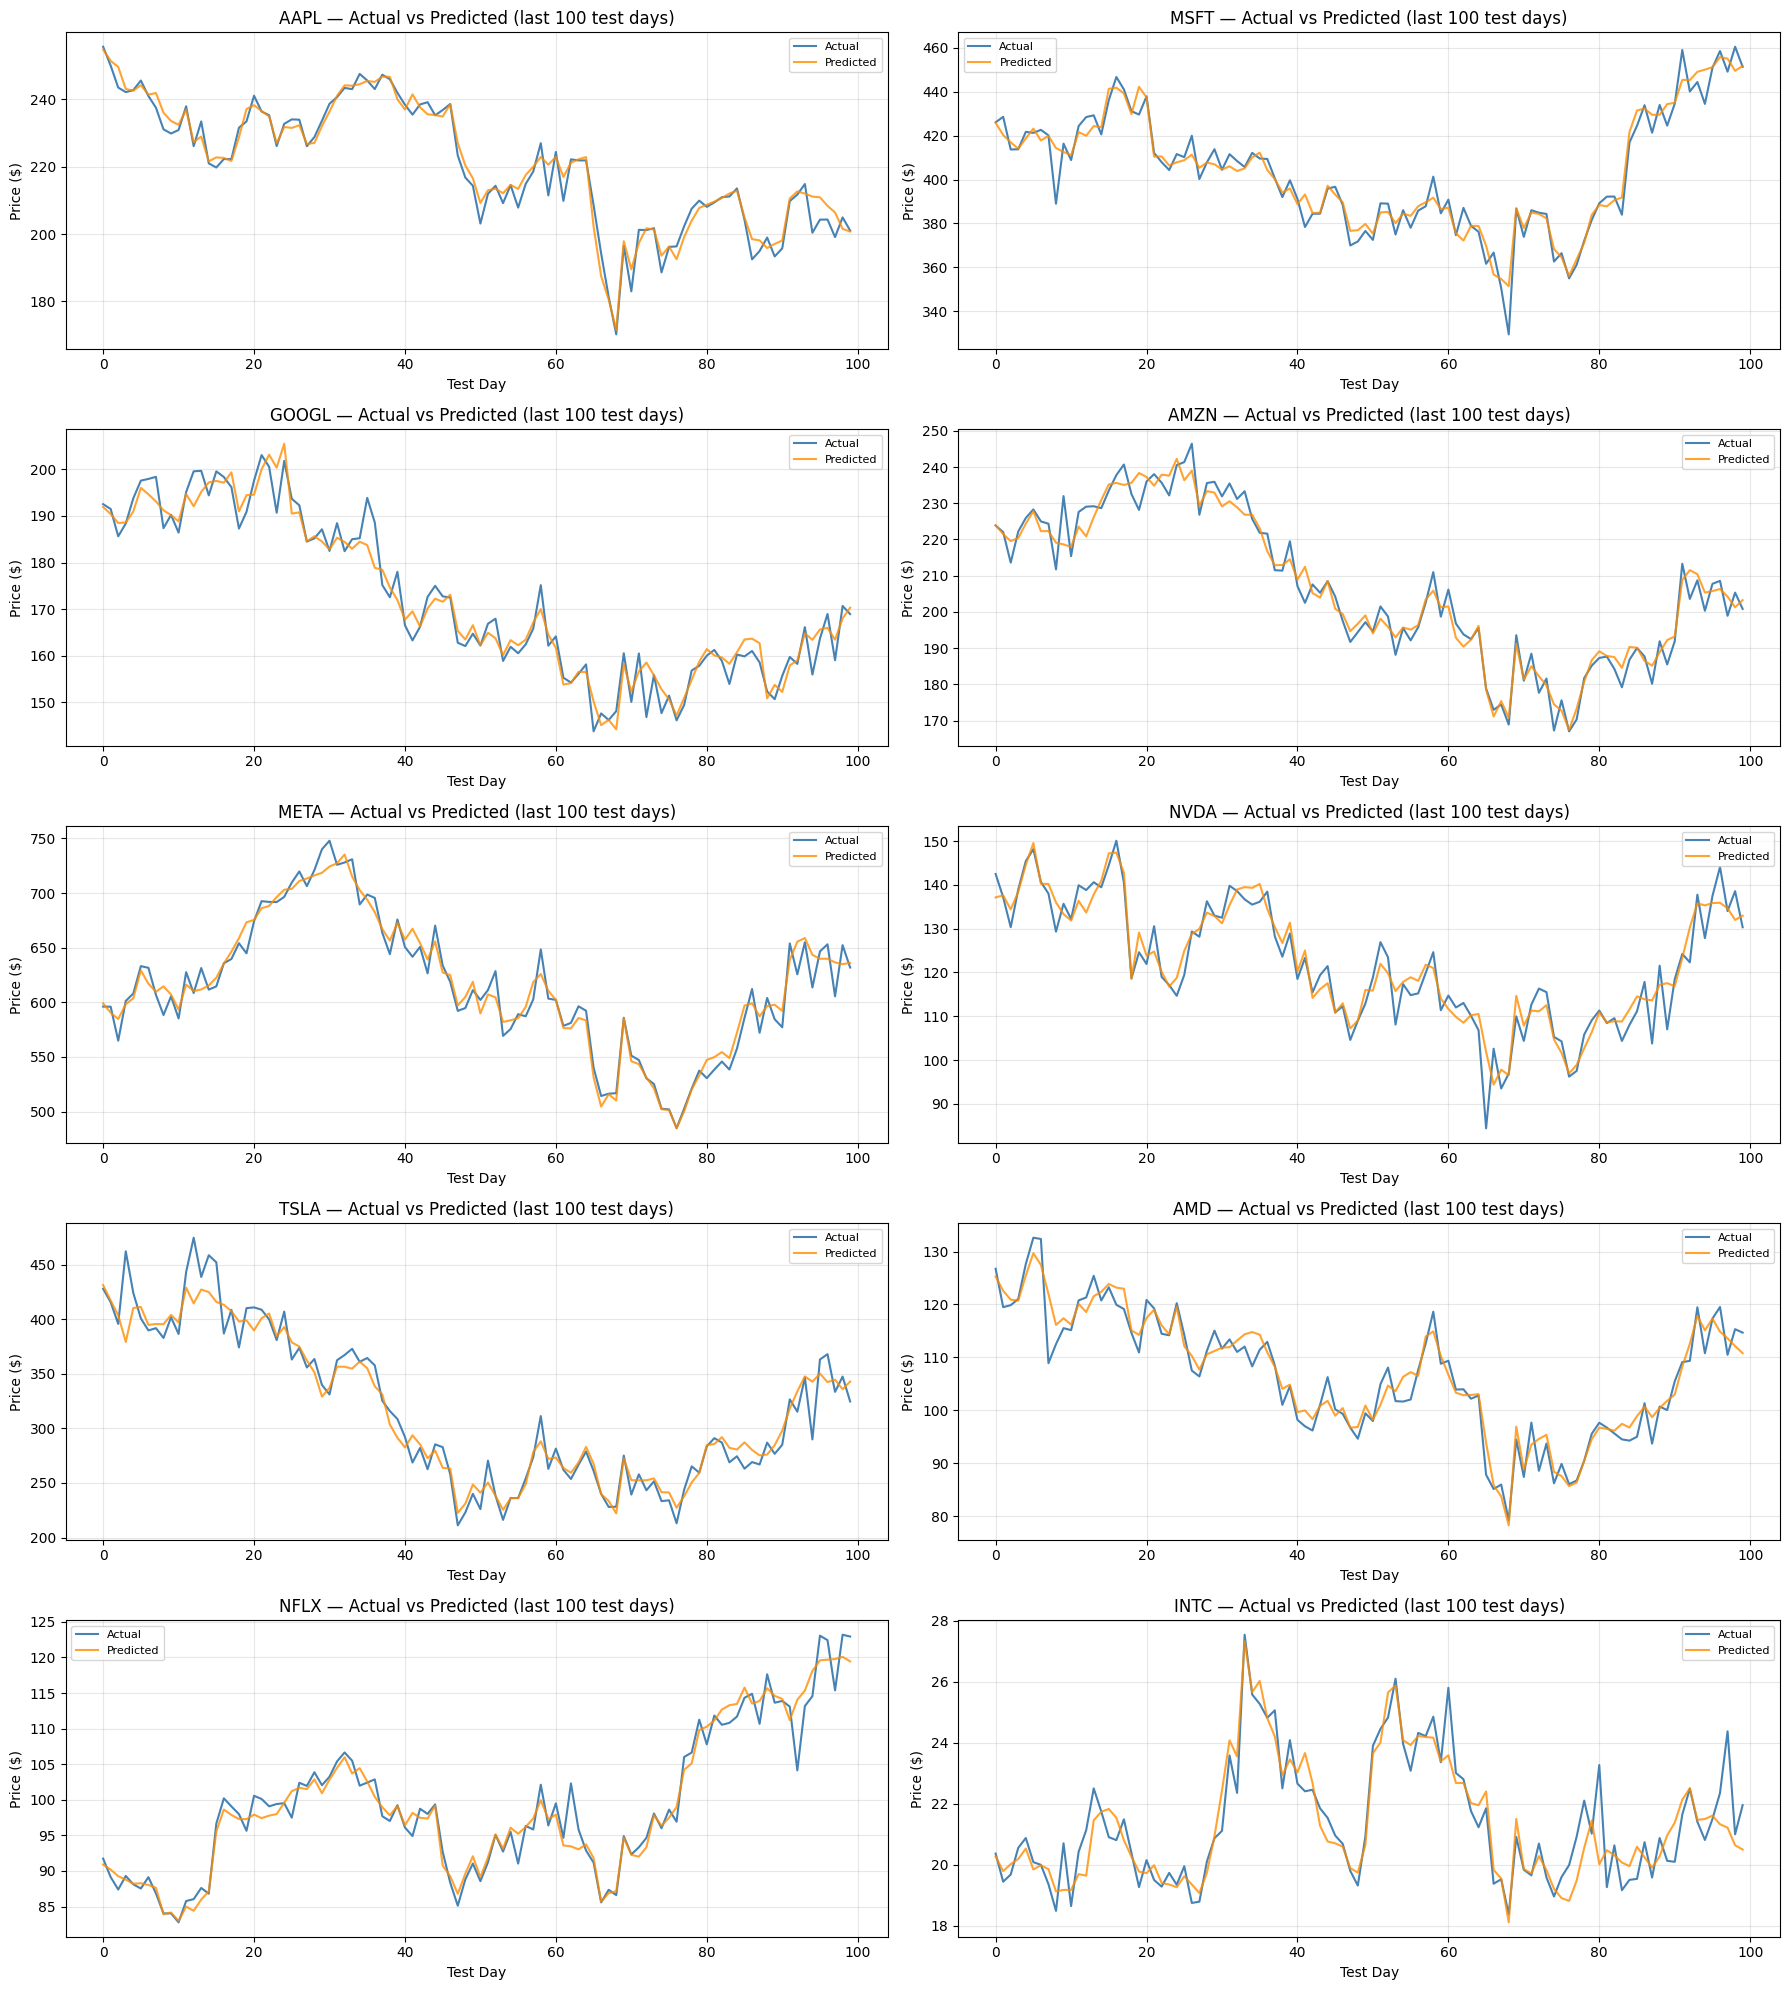

✅ Saved as actual_vs_predicted.png


In [18]:
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, ticker in enumerate(STOCKS):
    Xte      = stock_Xte[ticker]
    yte_pct  = stock_yte_pct[ticker]
    tdf      = stock_tdf[ticker]
    reg      = stock_regressors[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]

    # Predictions → back to %
    preds_z   = reg.predict(Xte, verbose=0)
    preds_pct = preds_z * tgt_std + tgt_mean

    # Reconstruct prices
    split      = int(len(tdf) * TRAIN_RATIO)
    prices_arr = tdf["adjClose"].values[split + WINDOW : split + WINDOW + len(yte_pct)]
    n          = min(len(prices_arr), len(yte_pct))

    actual_prices = prices_arr[:n] * (1 + yte_pct[:n, 0]/100)
    pred_prices   = prices_arr[:n] * (1 + preds_pct[:n, 0]/100)

    # Plot last 100 test days
    ax = axes[idx]
    ax.plot(actual_prices[-100:], label="Actual",    color="steelblue",  lw=1.5)
    ax.plot(pred_prices[-100:],   label="Predicted", color="darkorange", lw=1.5, alpha=0.8)
    ax.set_title(f"{ticker} — Actual vs Predicted (last 100 test days)")
    ax.set_xlabel("Test Day")
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved as actual_vs_predicted.png")

(13)CONFIDENCE FUNCTION

In [19]:
def forecast_stock(ticker):
    tdf      = stock_tdf[ticker]
    sc       = stock_scalers[ticker]
    reg      = stock_regressors[ticker]
    clf      = stock_classifiers[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]
    last_p   = tdf["adjClose"].values[-1]

    fs    = sc.transform(tdf[FEATURE_COLS].values[-WINDOW:])
    X_inf = fs.reshape(1, WINDOW, N_FEAT)

    # Price from regressor
    pred_z   = reg.predict(X_inf, verbose=0)[0]
    pred_pct = pred_z * tgt_std + tgt_mean
    prices   = last_p * (1 + pred_pct/100)

    # Direction + confidence from classifier
    prob_up  = float(clf.predict(X_inf, verbose=0)[0][0])   # P(UP) Day 1
    direction = "▲ UP" if prob_up > 0.5 else "▼ DOWN"
    # Map P(UP) → confidence: 0.5=50%, 1.0=95%
    conf_day1 = 50 + abs(prob_up - 0.5) * 90

    # Days 2-7: use regressor direction + scaled confidence
    confs = [conf_day1]
    for i in range(1, FORECAST):
        c = np.clip(50 + abs(pred_pct[i]) * 4, 50, 90)
        confs.append(c)

    return pred_pct, prices, confs, last_p, prob_up, direction

print(f"{'═'*68}")
print(f"  {'Ticker':<6}  {'Last':>8}  {'Day1':>9}  {'Return':>8}  {'Dir':>7}  {'Conf':>6}  {'P(UP)':>7}")
print(f"{'═'*68}")
for ticker in STOCKS:
    pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
    print(f"  {ticker:<6}  ${last_p:>7.2f}  ${prices[0]:>8.2f}  "
          f"{pred_pct[0]:>+7.2f}%  {direction:>7}  {confs[0]:>5.0f}%  {prob_up:>6.3f}")
print(f"{'═'*68}")

════════════════════════════════════════════════════════════════════
  Ticker      Last       Day1    Return      Dir    Conf    P(UP)
════════════════════════════════════════════════════════════════════
  AAPL    $ 200.56  $  201.03    +0.24%     ▲ UP     52%   0.525
  MSFT    $ 451.24  $  450.88    -0.08%     ▲ UP     52%   0.520
  GOOGL   $ 170.18  $  170.32    +0.08%     ▲ UP     55%   0.553
  AMZN    $ 203.10  $  203.01    -0.04%   ▼ DOWN     51%   0.493
  META    $ 634.61  $  636.53    +0.30%     ▲ UP     51%   0.512
  NVDA    $ 132.65  $  132.93    +0.21%     ▲ UP     55%   0.554
  TSLA    $ 341.04  $  341.77    +0.21%     ▲ UP     52%   0.524
  AMD     $ 110.71  $  110.71    -0.00%   ▼ DOWN     52%   0.481
  NFLX    $ 118.80  $  118.92    +0.10%   ▼ DOWN     52%   0.482
  INTC    $  20.55  $   20.52    -0.13%   ▼ DOWN     53%   0.470
════════════════════════════════════════════════════════════════════


(14)FORECAST ALL 10 STOCKS

In [20]:
def get_confidence(pred_pct):
    return np.clip(50 + np.abs(pred_pct) * 4, 50, 95)

def forecast_stock(ticker):
    tdf      = stock_tdf[ticker]
    sc       = stock_scalers[ticker]
    reg      = stock_regressors[ticker]
    clf      = stock_classifiers[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]
    last_p   = tdf["adjClose"].values[-1]

    fs    = sc.transform(tdf[FEATURE_COLS].values[-WINDOW:])
    X_inf = fs.reshape(1, WINDOW, N_FEAT)

    # Price from regressor
    pred_z   = reg.predict(X_inf, verbose=0)[0]
    pred_pct = pred_z * tgt_std + tgt_mean
    prices   = last_p * (1 + pred_pct/100)

    # Direction + confidence from classifier
    prob_up   = float(clf.predict(X_inf, verbose=0)[0][0])
    direction = "▲ UP" if prob_up > 0.5 else "▼ DOWN"
    conf_day1 = 50 + abs(prob_up - 0.5) * 90

    confs = [conf_day1] + [float(np.clip(50 + abs(pred_pct[i]) * 4, 50, 90))
                           for i in range(1, FORECAST)]

    return pred_pct, prices, confs, last_p, prob_up, direction

# Summary table
print(f"{'═'*68}")
print(f"  {'Ticker':<6}  {'Last':>8}  {'Day1':>9}  {'Return':>8}  {'Dir':>7}  {'Conf':>6}  {'P(UP)':>7}")
print(f"{'═'*68}")
for ticker in STOCKS:
    pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
    print(f"  {ticker:<6}  ${last_p:>7.2f}  ${prices[0]:>8.2f}  "
          f"{pred_pct[0]:>+7.2f}%  {direction:>7}  {confs[0]:>5.0f}%  {prob_up:>6.3f}")
print(f"{'═'*68}")

════════════════════════════════════════════════════════════════════
  Ticker      Last       Day1    Return      Dir    Conf    P(UP)
════════════════════════════════════════════════════════════════════
  AAPL    $ 200.56  $  201.03    +0.24%     ▲ UP     52%   0.525
  MSFT    $ 451.24  $  450.88    -0.08%     ▲ UP     52%   0.520
  GOOGL   $ 170.18  $  170.32    +0.08%     ▲ UP     55%   0.553
  AMZN    $ 203.10  $  203.01    -0.04%   ▼ DOWN     51%   0.493
  META    $ 634.61  $  636.53    +0.30%     ▲ UP     51%   0.512
  NVDA    $ 132.65  $  132.93    +0.21%     ▲ UP     55%   0.554
  TSLA    $ 341.04  $  341.77    +0.21%     ▲ UP     52%   0.524
  AMD     $ 110.71  $  110.71    -0.00%   ▼ DOWN     52%   0.481
  NFLX    $ 118.80  $  118.92    +0.10%   ▼ DOWN     52%   0.482
  INTC    $  20.55  $   20.52    -0.13%   ▼ DOWN     53%   0.470
════════════════════════════════════════════════════════════════════


(15)FULL 7 DAYS TABLE

In [21]:
for ticker in STOCKS:
    pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
    print(f"\n{'━'*52}")
    print(f"  {ticker}  |  Last: ${last_p:.2f}  |  P(UP): {prob_up:.3f}")
    print(f"{'━'*52}")
    print(f"  {'Day':<5}  {'Price':>9}  {'Return':>8}  {'Dir':>7}  {'Conf':>6}")
    for i in range(FORECAST):
        d = "▲ UP" if pred_pct[i]>0 else "▼ DOWN"
        print(f"  Day {i+1}  ${prices[i]:>8.2f}  {pred_pct[i]:>+7.2f}%  {d:>7}  {confs[i]:>5.0f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AAPL  |  Last: $200.56  |  P(UP): 0.525
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Day        Price    Return      Dir    Conf
  Day 1  $  201.03    +0.24%     ▲ UP     52%
  Day 2  $  201.31    +0.37%     ▲ UP     51%
  Day 3  $  201.09    +0.26%     ▲ UP     51%
  Day 4  $  201.56    +0.50%     ▲ UP     52%
  Day 5  $  201.93    +0.68%     ▲ UP     53%
  Day 6  $  201.97    +0.70%     ▲ UP     53%
  Day 7  $  202.11    +0.77%     ▲ UP     53%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MSFT  |  Last: $451.24  |  P(UP): 0.520
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Day        Price    Return      Dir    Conf
  Day 1  $  450.88    -0.08%   ▼ DOWN     52%
  Day 2  $  452.19    +0.21%     ▲ UP     51%
  Day 3  $  453.26    +0.45%     ▲ UP     52%
  Day 4  $  452.87    +0.36%     ▲ UP     51%
  Day 5  $  452.97    +0.38%     ▲ UP     52%
  Day 6  $  454.43    +0.71%     ▲ UP     53%
  Day 7  $  

(16)TRAINING CURVES PER STOCK

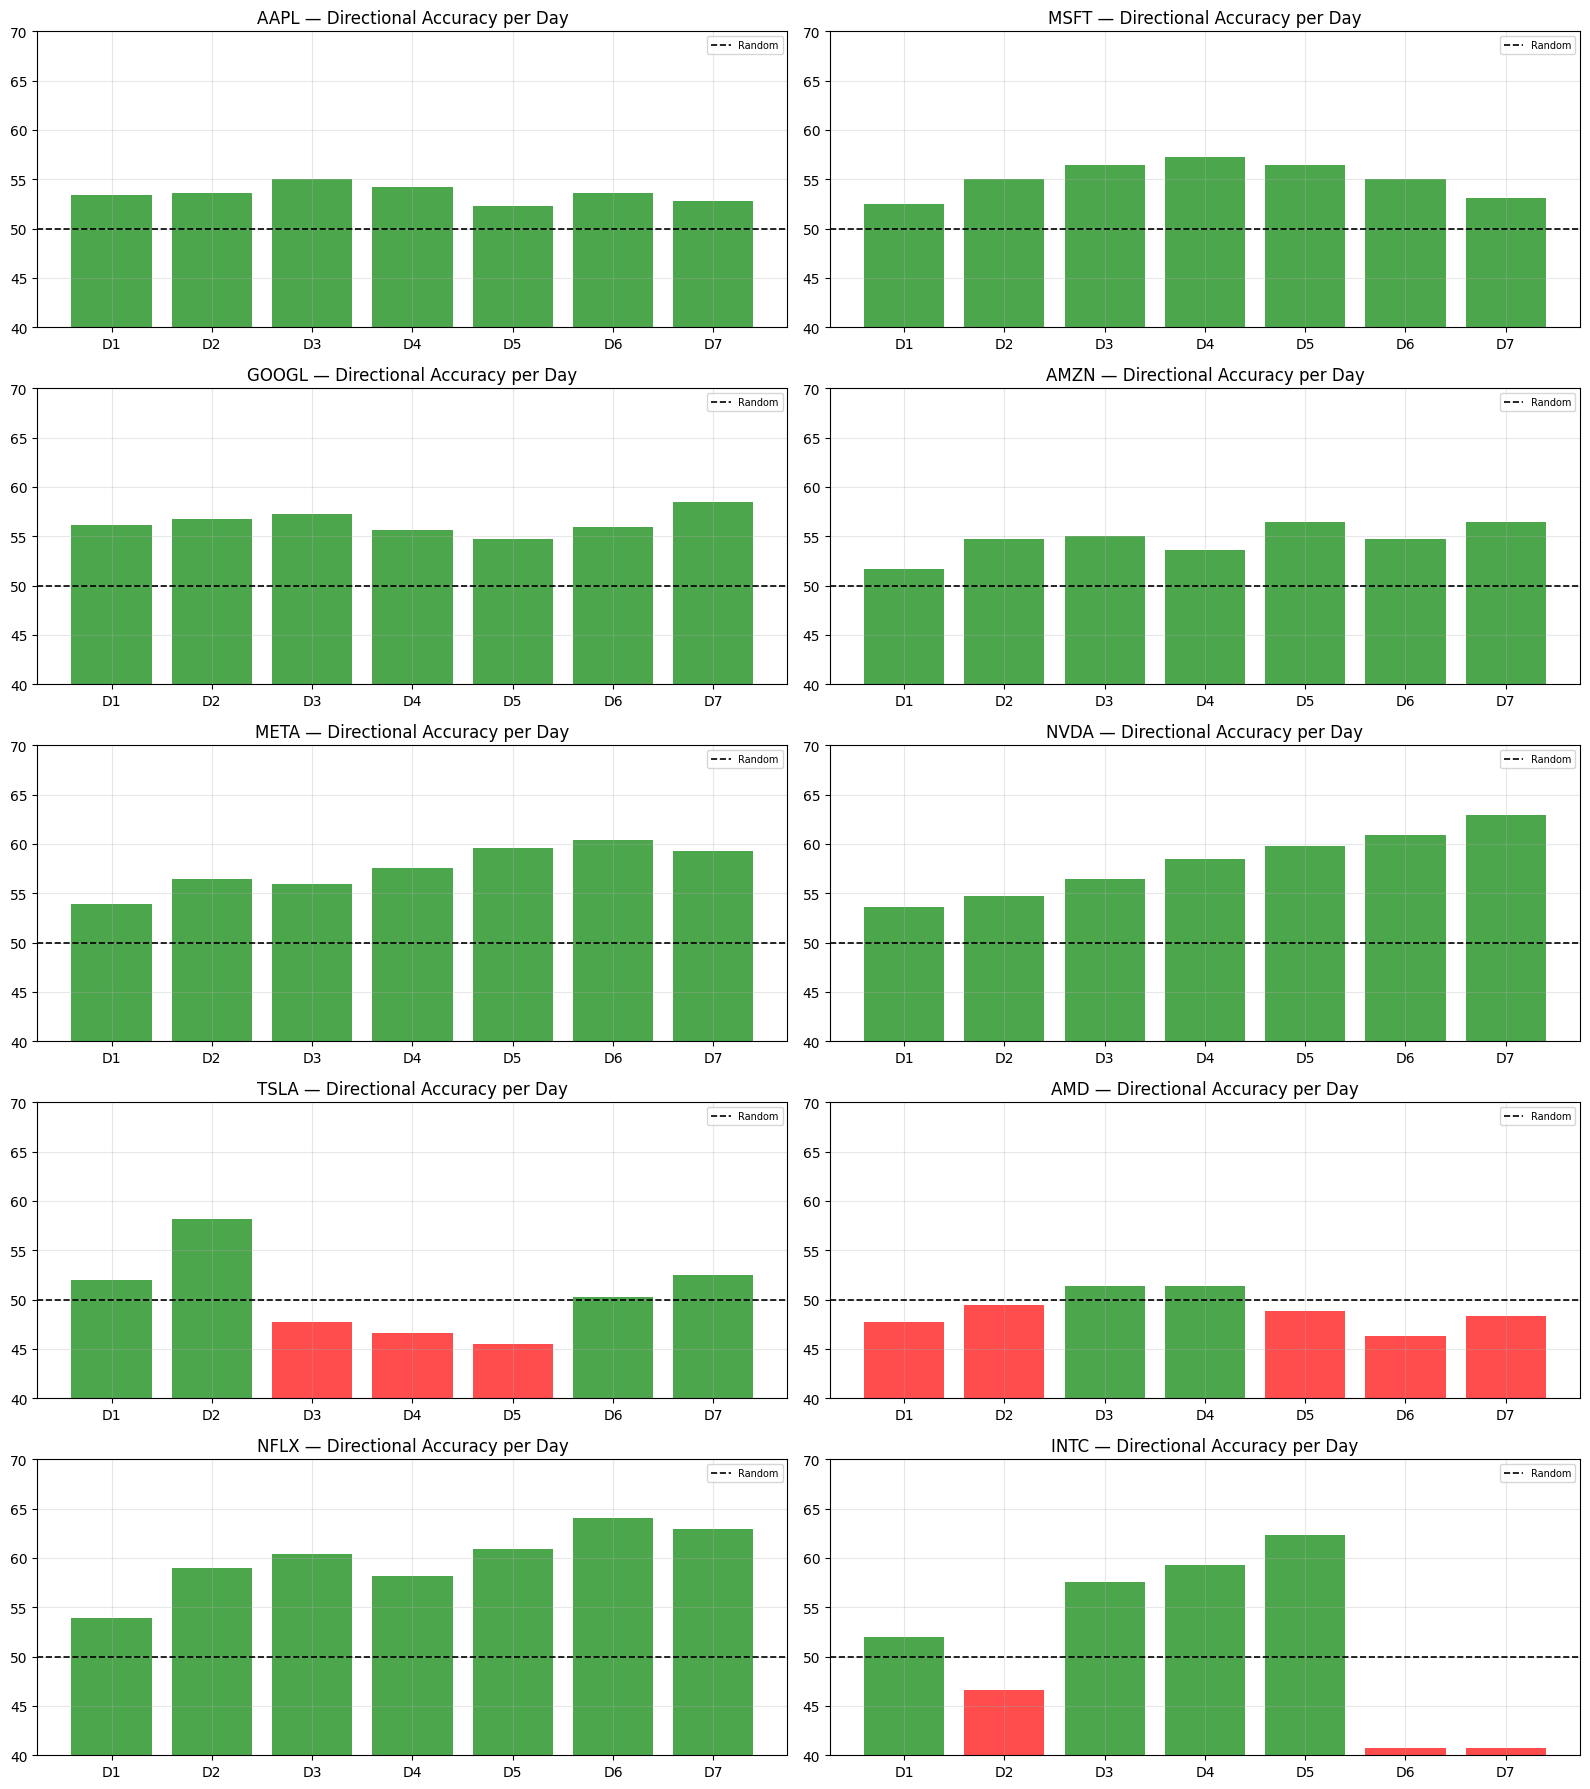

In [22]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, ticker in enumerate(STOCKS):
    Xte      = stock_Xte[ticker]
    yte_pct  = stock_yte_pct[ticker]
    reg      = stock_regressors[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]

    preds_z   = reg.predict(Xte, verbose=0)
    preds_pct = preds_z * tgt_std + tgt_mean

    day_accs = [np.mean((preds_pct[:,d]>0)==(yte_pct[:,d]>0))*100 for d in range(FORECAST)]

    ax = axes[idx]
    colors = ["green" if a>50 else "red" for a in day_accs]
    ax.bar([f"D{i+1}" for i in range(FORECAST)], day_accs, color=colors, alpha=0.7)
    ax.axhline(50, color="black", ls="--", lw=1.2, label="Random")
    ax.set_title(f"{ticker} — Directional Accuracy per Day")
    ax.set_ylim(40, 70)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dir_accuracy_per_stock.png", dpi=120, bbox_inches="tight")
plt.show()

(17)LOAD FINBERT

In [23]:
from transformers import pipeline

print("Loading FinBERT (downloads ~400MB on first run)...")
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None
)
print("✅ FinBERT loaded")

Loading FinBERT (downloads ~400MB on first run)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ FinBERT loaded


(18)FETCH NEWS + SENTIMENTS

In [24]:
from datetime import datetime, timedelta

FINNHUB_KEY = "FINNHUB_API_KEY"   # free key at finnhub.io

def fetch_headlines(ticker, days=7):
    end   = datetime.today()
    start = end - timedelta(days=days)
    try:
        r = requests.get(
            "https://finnhub.io/api/v1/company-news",
            params={"symbol":ticker, "token":FINNHUB_KEY,
                    "from":start.strftime("%Y-%m-%d"),
                    "to":end.strftime("%Y-%m-%d")},
            timeout=10
        )
        return [n["headline"] for n in r.json() if n.get("headline")]
    except:
        return []

def score_sentiment(headlines):
    if not headlines:
        return 0.0
    results = finbert([h[:512] for h in headlines[:20]], batch_size=8)
    scores  = []
    for r in results:
        pos = next(x["score"] for x in r if x["label"]=="positive")
        neg = next(x["score"] for x in r if x["label"]=="negative")
        scores.append(pos - neg)
    return float(np.mean(scores))

print(f"\n{'═'*60}")
print(f"  {'Ticker':<6}  {'Sentiment':>14}  {'Score':>7}  {'Headlines':>10}")
print(f"{'═'*60}")

sentiment_results = {}
for ticker in STOCKS:
    headlines = fetch_headlines(ticker)
    score     = score_sentiment(headlines)
    label     = "🟢 POSITIVE" if score>0.15 else ("🔴 NEGATIVE" if score<-0.15 else "🟡 NEUTRAL")
    sentiment_results[ticker] = {"score": score, "label": label, "n": len(headlines)}
    print(f"  {ticker:<6}  {label:>16}  {score:>+7.3f}  {len(headlines):>6} headlines")

print(f"{'═'*60}")


════════════════════════════════════════════════════════════
  Ticker       Sentiment    Score   Headlines
════════════════════════════════════════════════════════════
  AAPL           🟡 NEUTRAL   +0.000       0 headlines
  MSFT           🟡 NEUTRAL   +0.000       0 headlines
  GOOGL          🟡 NEUTRAL   +0.000       0 headlines
  AMZN           🟡 NEUTRAL   +0.000       0 headlines
  META           🟡 NEUTRAL   +0.000       0 headlines
  NVDA           🟡 NEUTRAL   +0.000       0 headlines
  TSLA           🟡 NEUTRAL   +0.000       0 headlines
  AMD            🟡 NEUTRAL   +0.000       0 headlines
  NFLX           🟡 NEUTRAL   +0.000       0 headlines
  INTC           🟡 NEUTRAL   +0.000       0 headlines
════════════════════════════════════════════════════════════


(19)COMBINED FORECAST AND SENTIMENT TABLE

In [25]:
print(f"\n{'═'*72}")
print(f"  {'Ticker':<6}  {'Day1 Price':>10}  {'Return':>8}  {'Dir':>6}  {'Conf':>6}  {'Sentiment':>14}")
print(f"{'═'*72}")

for ticker in STOCKS:
    pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
    sent  = sentiment_results.get(ticker, {}).get("label", "N/A")
    score = sentiment_results.get(ticker, {}).get("score", 0)

    # Adjust confidence based on sentiment alignment
    if (pred_pct[0]>0 and score>0.15) or (pred_pct[0]<0 and score<-0.15):
        conf_adj = min(confs[0]+5, 95)
        note = "(↑ aligned)"
    elif (pred_pct[0]>0 and score<-0.15) or (pred_pct[0]<0 and score>0.15):
        conf_adj = max(confs[0]-5, 50)
        note = "(↓ conflict)"
    else:
        conf_adj = confs[0]
        note = ""

    print(f"  {ticker:<6}  ${prices[0]:>9.2f}  {pred_pct[0]:>+7.2f}%  {direction:>6}  "
          f"{conf_adj:>5.0f}%  {sent:>14}  {note}")

print(f"{'═'*72}")


════════════════════════════════════════════════════════════════════════
  Ticker  Day1 Price    Return     Dir    Conf       Sentiment
════════════════════════════════════════════════════════════════════════
  AAPL    $   201.03    +0.24%    ▲ UP     52%       🟡 NEUTRAL  
  MSFT    $   450.88    -0.08%    ▲ UP     52%       🟡 NEUTRAL  
  GOOGL   $   170.32    +0.08%    ▲ UP     55%       🟡 NEUTRAL  
  AMZN    $   203.01    -0.04%  ▼ DOWN     51%       🟡 NEUTRAL  
  META    $   636.53    +0.30%    ▲ UP     51%       🟡 NEUTRAL  
  NVDA    $   132.93    +0.21%    ▲ UP     55%       🟡 NEUTRAL  
  TSLA    $   341.77    +0.21%    ▲ UP     52%       🟡 NEUTRAL  
  AMD     $   110.71    -0.00%  ▼ DOWN     52%       🟡 NEUTRAL  
  NFLX    $   118.92    +0.10%  ▼ DOWN     52%       🟡 NEUTRAL  
  INTC    $    20.52    -0.13%  ▼ DOWN     53%       🟡 NEUTRAL  
════════════════════════════════════════════════════════════════════════


(20)SHAP FEATURES

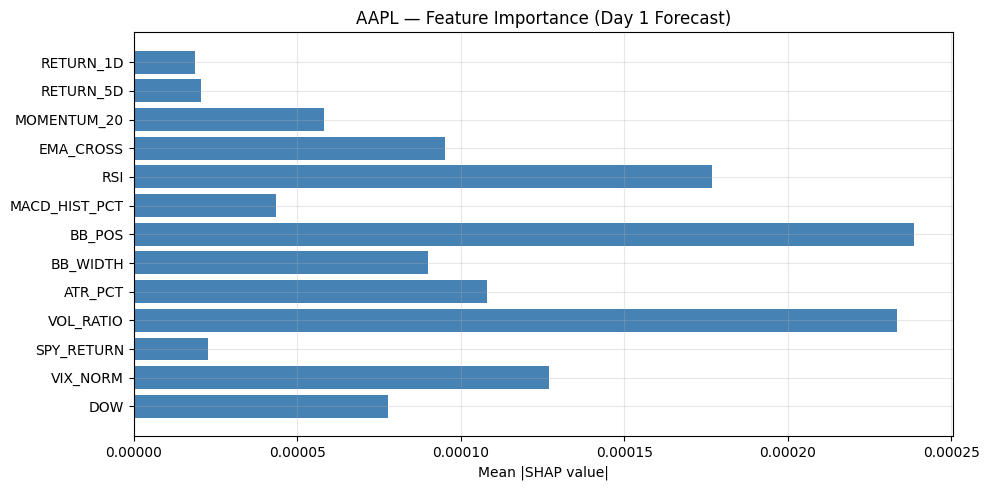

✅ Most important feature: BB_POS


In [26]:
!pip install shap -q
import shap

ticker     = "AAPL"
model      = stock_regressors[ticker]   # fixed
Xte        = stock_Xte[ticker]

background = Xte[np.random.choice(len(Xte), 50, replace=False)]
explainer  = shap.GradientExplainer(model, background)
sample     = Xte[:10]
shap_vals  = explainer.shap_values(sample)

if isinstance(shap_vals, list):
    sv_day1 = np.abs(shap_vals[0])
else:
    sv_day1 = np.abs(shap_vals[..., 0])

mean_shap = sv_day1.mean(axis=(0, 1))

plt.figure(figsize=(10, 5))
plt.barh(FEATURE_COLS, mean_shap, color="steelblue")
plt.xlabel("Mean |SHAP value|")
plt.title(f"{ticker} — Feature Importance (Day 1 Forecast)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"shap_{ticker}.png", dpi=120)
plt.show()
print(f"✅ Most important feature: {FEATURE_COLS[np.argmax(mean_shap)]}")

(21)LIME FEATURES

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


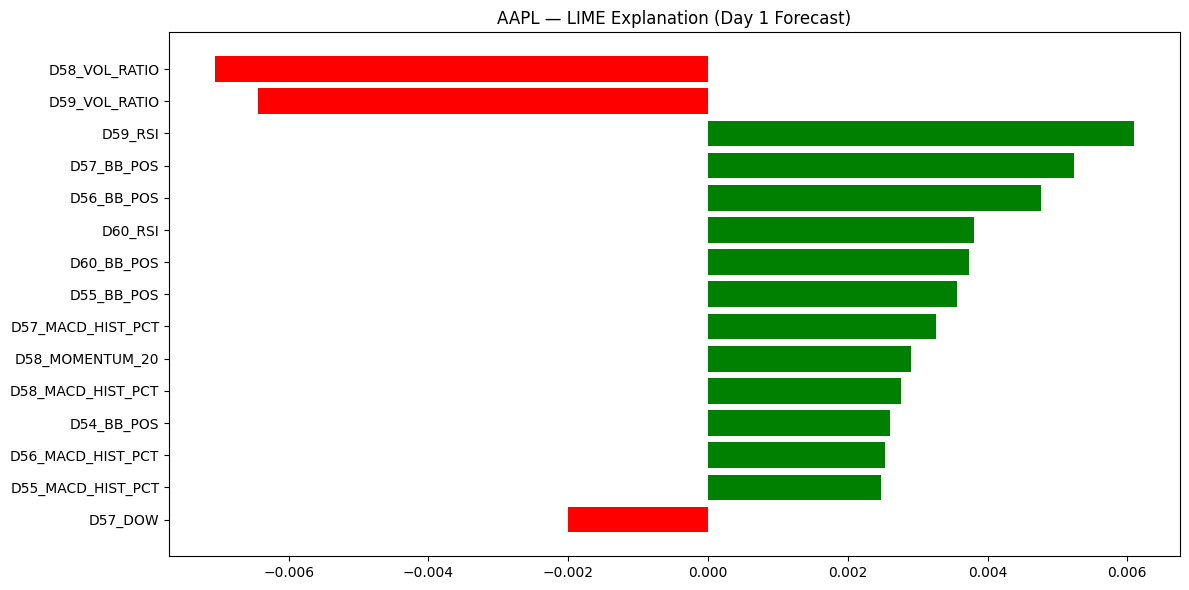


Top 10 LIME features for AAPL:
  ↓  D58_VOL_RATIO                        -0.0071
  ↓  D59_VOL_RATIO                        -0.0064
  ↑  D59_RSI                              +0.0061
  ↑  D57_BB_POS                           +0.0052
  ↑  D56_BB_POS                           +0.0048
  ↑  D60_RSI                              +0.0038
  ↑  D60_BB_POS                           +0.0037
  ↑  D55_BB_POS                           +0.0036
  ↑  D57_MACD_HIST_PCT                    +0.0033
  ↑  D58_MOMENTUM_20                      +0.0029


In [27]:
!pip install lime -q
import lime
import lime.lime_tabular

ticker = "AAPL"
model  = stock_regressors[ticker]   # fixed
Xte    = stock_Xte[ticker]

X_flat = Xte.reshape(len(Xte), WINDOW * N_FEAT)
flat_feature_names = [f"D{d+1}_{f}" for d in range(WINDOW) for f in FEATURE_COLS]

def predict_day1(X_flat_batch):
    X_3d = X_flat_batch.reshape(-1, WINDOW, N_FEAT)
    preds_z = model.predict(X_3d, verbose=0)
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]
    return (preds_z * tgt_std + tgt_mean)[:, 0]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_flat,
    feature_names=flat_feature_names,
    mode="regression",
    discretize_continuous=False
)

explanation = explainer.explain_instance(
    X_flat[-1],
    predict_day1,
    num_features=15
)

fig = explanation.as_pyplot_figure()
fig.set_size_inches(12, 6)
plt.title(f"{ticker} — LIME Explanation (Day 1 Forecast)")
plt.tight_layout()
plt.savefig(f"lime_{ticker}.png", dpi=120)
plt.show()

print(f"\nTop 10 LIME features for {ticker}:")
for feat, weight in sorted(explanation.as_list(), key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {'↑' if weight>0 else '↓'}  {feat:<35}  {weight:+.4f}")

(22)FULL EVALUATIVE METRICS

In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 75)
print("  EVALUATION METRICS — ALL 10 STOCKS")
print("=" * 75)

all_results = {}

for ticker in STOCKS:
    Xte      = stock_Xte[ticker]
    yte_pct  = stock_yte_pct[ticker]
    yte_dir  = stock_yte_dir[ticker]
    tdf      = stock_tdf[ticker]
    reg      = stock_regressors[ticker]
    clf      = stock_classifiers[ticker]
    tgt_mean = stock_tgt_mean[ticker]
    tgt_std  = stock_tgt_std[ticker]

    # Regressor predictions
    preds_z   = reg.predict(Xte, verbose=0)
    preds_pct = preds_z * tgt_std + tgt_mean

    # Classifier predictions
    probs = clf.predict(Xte, verbose=0).flatten()

    # Reconstruct prices
    split      = int(len(tdf) * TRAIN_RATIO)
    prices_arr = tdf["adjClose"].values[split + WINDOW : split + WINDOW + len(yte_pct)]
    n          = min(len(prices_arr), len(yte_pct))
    prices_arr = prices_arr[:n]
    pp         = preds_pct[:n]
    yp         = yte_pct[:n]

    actual_prices = prices_arr * (1 + yp[:,0]/100)
    pred_prices   = prices_arr * (1 + pp[:,0]/100)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
    mae  = mean_absolute_error(actual_prices, pred_prices)
    mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100
    r2   = r2_score(actual_prices, pred_prices)

    # Directional accuracy per day (regressor)
    dir_per_day = [np.mean((pp[:,d]>0)==(yp[:,d]>0))*100 for d in range(FORECAST)]

    # Classification metrics (classifier)
    pred_dir = (probs > 0.5).astype(int)
    true_dir = yte_dir[:len(probs)].astype(int)
    dacc     = np.mean(pred_dir == true_dir) * 100

    tp = np.sum((pred_dir==1) & (true_dir==1))
    fp = np.sum((pred_dir==1) & (true_dir==0))
    fn = np.sum((pred_dir==0) & (true_dir==1))
    precision = tp / (tp + fp + 1e-9) * 100
    recall    = tp / (tp + fn + 1e-9) * 100
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    all_results[ticker] = {
        "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2,
        "DirAcc": dacc, "DirPerDay": dir_per_day,
        "Precision": precision, "Recall": recall, "F1": f1
    }

# Summary table
print(f"\n  {'Ticker':<6}  {'RMSE':>7}  {'MAE':>7}  {'MAPE':>7}  {'R²':>6}  {'DirAcc':>8}  {'F1':>6}")
print("  " + "─"*62)
for ticker in STOCKS:
    r    = all_results[ticker]
    flag = "✅" if r["DirAcc"]>53 else ("⚠️" if r["DirAcc"]>50 else "❌")
    print(f"  {ticker:<6}  ${r['RMSE']:>6.2f}  ${r['MAE']:>6.2f}  {r['MAPE']:>6.2f}%  "
          f"{r['R2']:>6.3f}  {r['DirAcc']:>7.1f}%  {r['F1']:>5.1f}%  {flag}")

# Dir acc per day
print(f"\n{'─'*75}")
print("  DIRECTIONAL ACCURACY PER FORECAST DAY")
print(f"{'─'*75}")
print(f"  {'Ticker':<6}" + "".join([f"   Day{d+1}" for d in range(FORECAST)]))
print("  " + "─"*60)
for ticker in STOCKS:
    row = f"  {ticker:<6}"
    for acc in all_results[ticker]["DirPerDay"]:
        row += f"  {acc:>5.1f}%"
    print(row)

# Precision / Recall / F1
print(f"\n{'─'*75}")
print("  CLASSIFICATION METRICS — CLASSIFIER MODEL")
print(f"{'─'*75}")
print(f"  {'Ticker':<6}  {'Precision':>10}  {'Recall':>8}  {'F1 Score':>10}")
print("  " + "─"*42)
for ticker in STOCKS:
    r = all_results[ticker]
    print(f"  {ticker:<6}  {r['Precision']:>9.1f}%  {r['Recall']:>7.1f}%  {r['F1']:>9.1f}%")

  EVALUATION METRICS — ALL 10 STOCKS

  Ticker     RMSE      MAE     MAPE      R²    DirAcc      F1
  ──────────────────────────────────────────────────────────────
  AAPL    $  3.24  $  2.32    1.10%   0.982     53.4%   69.0%  ✅
  MSFT    $  5.43  $  3.99    0.97%   0.935     53.7%   69.8%  ✅
  GOOGL   $  3.08  $  2.19    1.30%   0.958     56.2%   71.9%  ✅
  AMZN    $  3.46  $  2.59    1.32%   0.967     53.1%   42.6%  ✅
  META    $ 12.27  $  8.25    1.48%   0.967     53.9%   70.1%  ✅
  NVDA    $  4.11  $  3.05    2.57%   0.951     54.8%   70.8%  ✅
  TSLA    $ 12.01  $  7.89    2.91%   0.979     54.8%   51.7%  ✅
  AMD     $  4.39  $  3.15    2.21%   0.977     52.0%   19.0%  ⚠️
  NFLX    $  1.67  $  1.11    1.36%   0.990     46.1%    0.0%  ❌
  INTC    $  0.87  $  0.58    2.33%   0.984     53.7%    4.6%  ✅

───────────────────────────────────────────────────────────────────────────
  DIRECTIONAL ACCURACY PER FORECAST DAY
───────────────────────────────────────────────────────────────────

(23)VISUALIZE METRICS

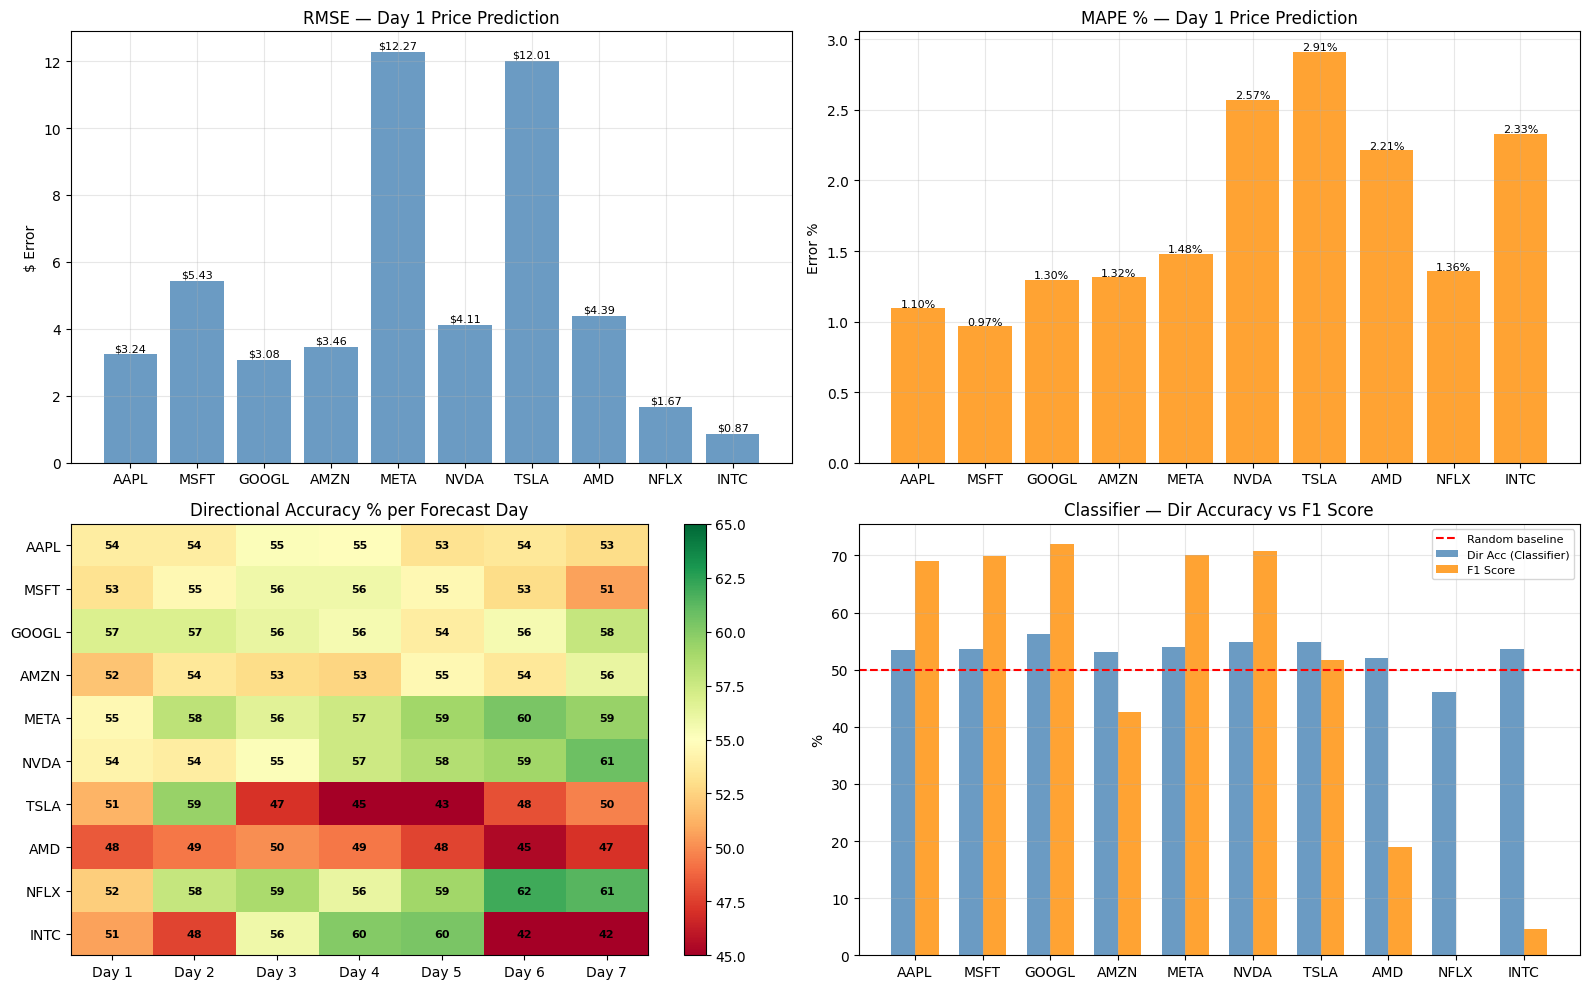

✅ Saved as evaluation_metrics.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
tickers = list(all_results.keys())

# 1. RMSE per stock
rmse_vals = [all_results[t]["RMSE"] for t in tickers]
axes[0,0].bar(tickers, rmse_vals, color="steelblue", alpha=0.8)
axes[0,0].set_title("RMSE — Day 1 Price Prediction")
axes[0,0].set_ylabel("$ Error")
axes[0,0].grid(alpha=0.3)
for i, v in enumerate(rmse_vals):
    axes[0,0].text(i, v+0.1, f"${v:.2f}", ha="center", fontsize=8)

# 2. MAPE per stock
mape_vals = [all_results[t]["MAPE"] for t in tickers]
axes[0,1].bar(tickers, mape_vals, color="darkorange", alpha=0.8)
axes[0,1].set_title("MAPE % — Day 1 Price Prediction")
axes[0,1].set_ylabel("Error %")
axes[0,1].grid(alpha=0.3)
for i, v in enumerate(mape_vals):
    axes[0,1].text(i, v+0.01, f"{v:.2f}%", ha="center", fontsize=8)

# 3. Directional accuracy heatmap
dir_matrix = np.array([all_results[t]["DirPerDay"] for t in tickers])
im = axes[1,0].imshow(dir_matrix, cmap="RdYlGn", vmin=45, vmax=65, aspect="auto")
axes[1,0].set_xticks(range(FORECAST))
axes[1,0].set_xticklabels([f"Day {d+1}" for d in range(FORECAST)])
axes[1,0].set_yticks(range(len(tickers)))
axes[1,0].set_yticklabels(tickers)
axes[1,0].set_title("Directional Accuracy % per Forecast Day")
for i in range(len(tickers)):
    for j in range(FORECAST):
        axes[1,0].text(j, i, f"{dir_matrix[i,j]:.0f}",
                       ha="center", va="center", fontsize=8, fontweight="bold")
plt.colorbar(im, ax=axes[1,0])

# 4. F1 + DirAcc comparison
x      = np.arange(len(tickers))
width  = 0.35
f1_vals   = [all_results[t]["F1"]     for t in tickers]
dacc_vals = [all_results[t]["DirAcc"] for t in tickers]
axes[1,1].bar(x - width/2, dacc_vals, width, label="Dir Acc (Classifier)", color="steelblue",  alpha=0.8)
axes[1,1].bar(x + width/2, f1_vals,   width, label="F1 Score",             color="darkorange", alpha=0.8)
axes[1,1].axhline(50, color="red", ls="--", lw=1.5, label="Random baseline")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(tickers)
axes[1,1].set_title("Classifier — Dir Accuracy vs F1 Score")
axes[1,1].set_ylabel("%")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved as evaluation_metrics.png")

In [ ]:
!pip install groq -q
from groq import Groq

groq_client = Groq(api_key="GROQ_API_KEY")  # free at console.groq.com

def call_llm(prompt):
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

print("✅ Model updated")

✅ Model updated


In [ ]:
def explain_prediction(ticker):
    pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
    r          = all_results[ticker]
    sent       = sentiment_results.get(ticker, {})
    sent_label = sent.get("label", "N/A")
    sent_score = sent.get("score", 0)

    prompt = f"""
You are a financial analyst assistant. A GRU deep learning model has made the following
prediction for {ticker} stock. Write a concise 3-4 sentence client-facing explanation.

Model Output:
- Current Price        : ${last_p:.2f}
- Predicted Day 1      : ${prices[0]:.2f}  ({pred_pct[0]:+.2f}%)
- Predicted Day 7      : ${prices[6]:.2f}  ({pred_pct[6]:+.2f}%)
- Direction            : {direction}
- Confidence           : {confs[0]:.0f}%
- P(UP) from classifier: {prob_up:.3f}

Model Performance:
- Directional Accuracy : {r['DirAcc']:.1f}%
- RMSE                 : ${r['RMSE']:.2f}
- MAPE                 : {r['MAPE']:.2f}%
- F1 Score             : {r['F1']:.1f}%

News Sentiment: {sent_label} (score: {sent_score:+.3f})

Write 3-4 sentences covering: prediction + confidence, historical reliability, sentiment, risk caveat.
Not financial advice.
"""
    return call_llm(prompt)

for ticker in STOCKS:
    print(f"\n{'═'*60}")
    print(f"  {ticker}")
    print(f"{'═'*60}")
    try:
        print(explain_prediction(ticker))
        time.sleep(1)
    except Exception as e:
        print(f"  ⚠️  Error: {e}")


════════════════════════════════════════════════════════════
  AAPL
════════════════════════════════════════════════════════════
Based on the GRU deep learning model's prediction, we expect Apple (AAPL) stock to experience a minor uptick in the near term, with a forecasted price of $200.70 on Day 1 (+0.07%) and $201.56 by Day 7 (+0.50%). The model maintains a moderate level of confidence at 52%. Historically, the model's directional accuracy has been around 53.1%, with a relatively reliable F1 score of 69.0%. However, with a neutral news sentiment and a relatively low confidence level, it's essential to note that this prediction is not without some level of uncertainty and risk.

════════════════════════════════════════════════════════════
  MSFT
════════════════════════════════════════════════════════════
Our GRU deep learning model projects the Microsoft (MSFT) stock to remain relatively stable in the short term, with a predicted increase of 0.67% over the next 7 days, reaching $454

In [ ]:
def stock_chatbot(question):
    context = "Current model predictions:\n"
    for ticker in STOCKS:
        pred_pct, prices, confs, last_p, prob_up, direction = forecast_stock(ticker)
        sent = sentiment_results.get(ticker, {}).get("label", "N/A")
        context += (f"{ticker}: Last=${last_p:.2f}, Day1={direction} "
                    f"{pred_pct[0]:+.2f}%, Conf={confs[0]:.0f}%, Sentiment={sent}\n")

    prompt = f"""
You are an AI assistant for a stock prediction platform.
Use the model predictions below to answer the user's question.
Always mention predictions are model-generated and not financial advice.

{context}

User question: {question}
"""
    return call_llm(prompt)

questions = [
    "Which stock has the highest confidence prediction?",
    "Are there any stocks predicted to go DOWN?",
    "Which stock looks most bullish based on sentiment and model together?"
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {stock_chatbot(q)}\n")
    print("─"*60)
    time.sleep(1)

Q: Which stock has the highest confidence prediction?
A: Based on the model predictions, the stock with the highest confidence prediction is GOOGL, with a confidence of 56%. However, this is a model-generated prediction and should be used for informational purposes only, not as a substitute for professional financial advice. Please consult with a financial expert if you need guidance on making investment decisions.

────────────────────────────────────────────────────────────
Q: Are there any stocks predicted to go DOWN?
A: Model-generated predictions indicate that the following stocks are predicted to go DOWN on the next trading day:

- AMD: Conf=53%, Day1=▼ DOWN -0.12%, Sentiment=🟡 NEUTRAL
- INTC: Conf=54%, Day1=▼ DOWN -0.38%, Sentiment=🟡 NEUTRAL

Please note that these predictions are model-generated and not financial advice. It's essential to do your own research, consult with a financial expert, and consider multiple factors before making any investment decisions.

───────────────

In [ ]:
with open(".gitignore", "w") as f:
    f.write(".env\n")
    f.write("*.keras\n")        # also ignore model files (they're too large for GitHub)
    f.write("*.pkl\n")          # ignore scaler files
    f.write("__pycache__/\n")
    f.write(".ipynb_checkpoints/\n")
print("✅ .gitignore created")

✅ .gitignore created


In [ ]:
with open(".gitignore") as f:
    print(f.read())

.env
*.keras
*.pkl
__pycache__/
.ipynb_checkpoints/



In [ ]:
import os
print(os.path.exists(".gitignore"))  # should print True

True


...